# Data Science Job Salaries
## Exploratory Data Analysis & Statistical Analysis

### Research Objective

This analysis looks at salary differences in data science jobs and how they relate to experience, role, company size, remote work, location, and year.

### Research Questions

1. Does salary increase with experience level?
2. Which job titles have the highest typical salaries?
3. Does company size relate to salary?
4. Do salaries differ by remote-work arrangement?
5. Which company locations have higher salaries?
6. How do salaries change over the available years?
7. Is there a salary difference between Data Scientists and Data Analysts?


## Research Hypotheses

These hypotheses guide the comparisons in the EDA. They are evaluated using descriptive and comparative analysis.

### 1. Experience Level and Salary
**H₀:** Salary levels do not differ meaningfully across experience levels.  
**H₁:** Salary levels differ meaningfully across experience levels.

### 2. Job Title and Salary
**H₀:** Salary levels do not differ meaningfully across job titles.  
**H₁:** Salary levels differ meaningfully across job titles.

### 3. Company Size and Salary
**H₀:** Salary levels do not differ meaningfully across company sizes.  
**H₁:** Salary levels differ meaningfully across company sizes.

### 4. Remote Work and Salary
**H₀:** Salary levels do not differ meaningfully across remote-work arrangements.  
**H₁:** Salary levels differ meaningfully across remote-work arrangements.

### 5. Company Location and Salary
**H₀:** Salary levels do not differ meaningfully across company locations.  
**H₁:** Salary levels differ meaningfully across company locations.

### 6. Salary Over Time
**H₀:** Salary levels do not show a meaningful change across the available years.  
**H₁:** Salary levels show a meaningful change across the available years.

### 7. Data Scientist vs Data Analyst
**H₀:** There is no meaningful salary difference between the two roles.  
**H₁:** There is a meaningful salary difference between the two roles.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cleaned_dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.shape

(607, 11)

In [5]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [6]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


## Dataset Overview

The cleaned dataset is used for the analysis. `salary_in_usd` is the main salary measure because it puts all records on the same currency scale.


### Variable Interpretation

- `work_year`: year of the salary record
- `experience_level`: experience category
- `employment_type`: employment type
- `job_title`: job role
- `salary`: original salary
- `salary_currency`: original currency
- `salary_in_usd`: salary converted to USD
- `employee_residence`: employee's country
- `remote_ratio`: remote-work percentage
- `company_location`: company country
- `company_size`: company size


## Analytical Approach

We use descriptive statistics, distributions, group comparisons, trends, and correlation analysis.

Mean and median are used together because salaries can vary widely and may be skewed.


In [8]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


In [9]:
salary_stats = df['salary_in_usd'].describe()

salary_stats

,salary_in_usd
count,607.000000
mean,112297.869852
std,70957.259411
min,2859.000000
25%,62726.000000
50%,101570.000000
75%,150000.000000
max,600000.000000


In [10]:
salary_summary = {
    'Mean': df['salary_in_usd'].mean(),
    'Median': df['salary_in_usd'].median(),
    'Standard Deviation': df['salary_in_usd'].std(),
    'Minimum': df['salary_in_usd'].min(),
    'Maximum': df['salary_in_usd'].max()
}

salary_summary

{'Mean': np.float64(112297.86985172982),
 'Median': 101570.0,
 'Standard Deviation': 70957.2594113957,
 'Minimum': 2859,
 'Maximum': 600000}

## Descriptive Statistics

We use mean, median, standard deviation, minimum, and maximum to describe the salary data.


### Initial Salary Findings

The mean salary is about $112,298, while the median is $101,570. The higher mean suggests that some higher salaries are pulling the average upward.


## Salary Distribution

A histogram is used to see where salaries are concentrated and how spread out they are.


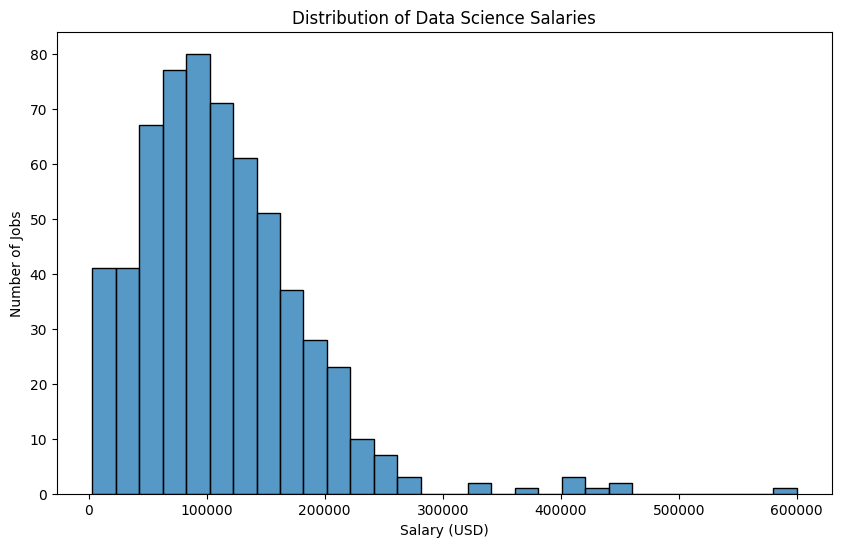

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='salary_in_usd',
    bins=30
)

plt.title('Distribution of Data Science Salaries')
plt.xlabel('Salary (USD)')
plt.ylabel('Number of Jobs')

plt.show()

### Salary Spread and Potential Outliers

The boxplot gives a quick view of the salary spread and highlights unusually high or low observations.


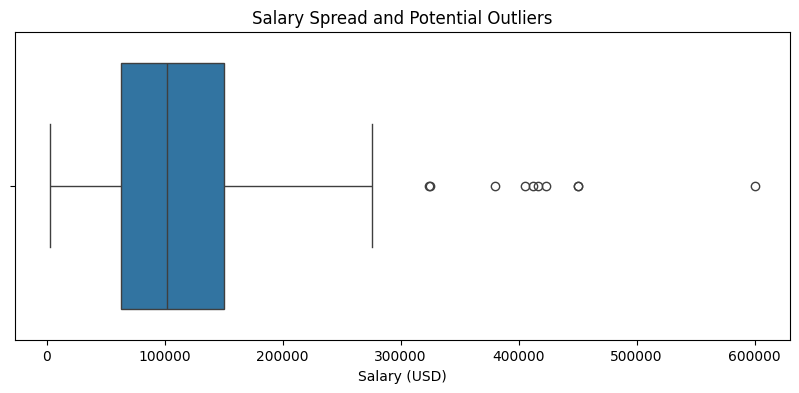

In [12]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['salary_in_usd']
)

plt.title('Salary Spread and Potential Outliers')
plt.xlabel('Salary (USD)')

plt.show()

### Salary Distribution Findings

Salaries vary considerably. The mean ($112,297.87) is higher than the median ($101,570), which is consistent with a right-skewed distribution. The wide range also shows substantial variation between jobs.


## Salary by Experience Level

### Business Question

Does salary increase with experience level?

We compare mean, median, and number of records across the four experience groups.


In [13]:
experience_salary = (
    df.groupby('experience_level')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

experience_salary

,experience_level,mean,median,count
0,EN,61643.318182,56500.0,88
1,EX,199392.038462,171437.5,26
2,MI,87996.056338,76940.0,213
3,SE,138617.292857,135500.0,280


In [14]:
experience_salary['experience_label'] = experience_salary['experience_level'].map({
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive-level'
})

experience_salary

,experience_level,mean,median,count,experience_label
0,EN,61643.318182,56500.0,88,Entry-level
1,EX,199392.038462,171437.5,26,Executive-level
2,MI,87996.056338,76940.0,213,Mid-level
3,SE,138617.292857,135500.0,280,Senior-level


In [15]:
experience_order = [
    'Entry-level',
    'Mid-level',
    'Senior-level',
    'Executive-level'
]

experience_salary['experience_label'] = pd.Categorical(
    experience_salary['experience_label'],
    categories=experience_order,
    ordered=True
)

experience_salary = experience_salary.sort_values('experience_label')

experience_salary

,experience_level,mean,median,count,experience_label
0,EN,61643.318182,56500.0,88,Entry-level
2,MI,87996.056338,76940.0,213,Mid-level
3,SE,138617.292857,135500.0,280,Senior-level
1,EX,199392.038462,171437.5,26,Executive-level


### Salary Progression by Experience Level

Mean and median salaries are compared across experience levels to see how compensation changes as experience increases.


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    experience_salary['experience_label'],
    experience_salary['mean'],
    marker='o',
    label='Mean Salary'
)

plt.plot(
    experience_salary['experience_label'],
    experience_salary['median'],
    marker='o',
    label='Median Salary'
)

plt.title('Salary Progression by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.legend()

plt.tight_layout()
plt.show()


### Experience and Salary Findings

Salary rises across the experience groups. Executive-level roles have the highest mean and median salaries, while Entry-level roles have the lowest.


## Salary by Job Title

### Business Question

Which job titles have the highest typical salaries?

We first look at the most represented roles, then compare their median salaries.


In [17]:
job_salary = (
    df.groupby('job_title')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

job_salary

,job_title,mean,median,count
0,3D Computer Vision Researcher,5409.000000,5409.0,1
1,AI Scientist,66135.571429,45896.0,7
2,Analytics Engineer,175000.000000,179850.0,4
3,Applied Data Scientist,175655.000000,157000.0,5
4,Applied Machine Learning Scientist,142068.750000,56700.0,4
5,BI Data Analyst,74755.166667,76500.0,6
6,Big Data Architect,99703.000000,99703.0,1
7,Big Data Engineer,51974.000000,41305.5,8
8,Business Data Analyst,76691.200000,70912.0,5
9,Cloud Data Engineer,124647.000000,124647.0,2


In [18]:
job_salary.sort_values(
    by='count',
    ascending=False
).head(10)

,job_title,mean,median,count
22,Data Scientist,108187.832168,103691.0,143
17,Data Engineer,112725.000000,105500.0,132
12,Data Analyst,92893.061856,90320.0,97
38,Machine Learning Engineer,104880.146341,87932.0,41
48,Research Scientist,109019.500000,76263.5,16
21,Data Science Manager,158328.500000,155750.0,12
16,Data Architect,177873.909091,180000.0,11
7,Big Data Engineer,51974.000000,41305.5,8
41,Machine Learning Scientist,158412.500000,156500.0,8
15,Data Analytics Manager,127134.285714,120000.0,7


In [19]:
top_jobs = (
    job_salary
    .sort_values(by='count', ascending=False)
    .head(10)
)

top_jobs

,job_title,mean,median,count
22,Data Scientist,108187.832168,103691.0,143
17,Data Engineer,112725.000000,105500.0,132
12,Data Analyst,92893.061856,90320.0,97
38,Machine Learning Engineer,104880.146341,87932.0,41
48,Research Scientist,109019.500000,76263.5,16
21,Data Science Manager,158328.500000,155750.0,12
16,Data Architect,177873.909091,180000.0,11
7,Big Data Engineer,51974.000000,41305.5,8
41,Machine Learning Scientist,158412.500000,156500.0,8
15,Data Analytics Manager,127134.285714,120000.0,7


In [20]:
top_jobs_by_salary = (
    top_jobs
    .sort_values(by='median', ascending=False)
)

top_jobs_by_salary

,job_title,mean,median,count
16,Data Architect,177873.909091,180000.0,11
41,Machine Learning Scientist,158412.500000,156500.0,8
21,Data Science Manager,158328.500000,155750.0,12
15,Data Analytics Manager,127134.285714,120000.0,7
17,Data Engineer,112725.000000,105500.0,132
22,Data Scientist,108187.832168,103691.0,143
12,Data Analyst,92893.061856,90320.0,97
38,Machine Learning Engineer,104880.146341,87932.0,41
48,Research Scientist,109019.500000,76263.5,16
7,Big Data Engineer,51974.000000,41305.5,8


### Top Job Titles by Typical Salary

The 10 most represented job titles are compared using median salary.


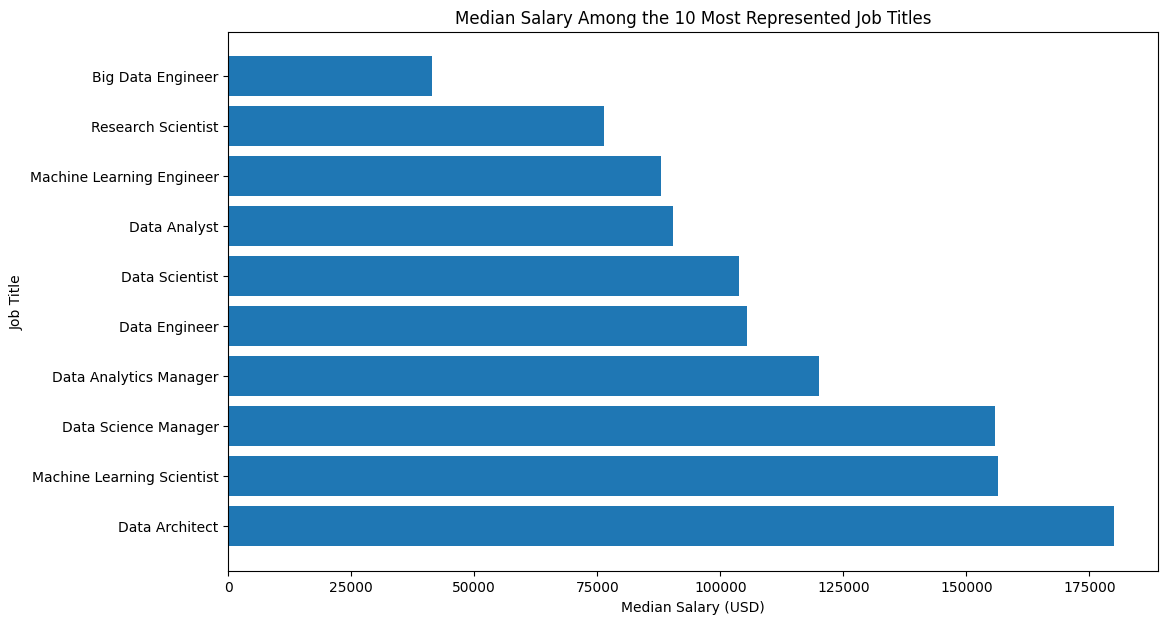

In [22]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_jobs_by_salary['job_title'],
    top_jobs_by_salary['median']
)

plt.title('Median Salary Among the 10 Most Represented Job Titles')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Job Title')

plt.show()

### Job Title Salary Findings

Among the 10 most represented roles, Data Architect has the highest median salary, followed by Machine Learning Scientist and Data Science Manager.


## Salary by Company Size

### Business Question

Is company size associated with salary differences?

We compare mean, median, and record count across Small, Medium, and Large companies.


In [23]:
company_salary = (
    df.groupby('company_size')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

company_salary

,company_size,mean,median,count
0,L,119242.994949,100000.0,198
1,M,116905.466258,113188.0,326
2,S,77632.674699,65000.0,83


In [24]:
company_salary.sort_values(
    by='median',
    ascending=False
)

,company_size,mean,median,count
1,M,116905.466258,113188.0,326
0,L,119242.994949,100000.0,198
2,S,77632.674699,65000.0,83


### Salary Distribution by Company Size

The boxplot shows how salary distributions differ across the three company-size groups.


In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='company_size',
    y='salary_in_usd'
)

plt.title('Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')

plt.tight_layout()
plt.show()


### Company Size and Salary Findings

Small companies have the lowest salary levels. Medium and Large companies show higher typical salaries, although there is still considerable variation within each group.


## Employment Type Context

Employment type is included for context. Most records are full-time, so the main work-arrangement comparison uses `remote_ratio`.


In [ ]:
employment_counts = (
    df['employment_type']
    .value_counts()
    .rename_axis('employment_type')
    .reset_index(name='count')
)

employment_counts


## Salary by Remote Work Arrangement

### Business Question

Do salary levels differ by remote-work arrangement?

We compare mean, median, and record count for on-site, hybrid, and fully remote roles.


In [26]:
remote_salary = (
    df.groupby('remote_ratio')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

remote_salary

,remote_ratio,mean,median,count
0,0,106354.622047,99000.0,127
1,50,80823.030303,69999.0,99
2,100,122457.454068,115000.0,381


In [27]:
remote_salary.sort_values(
    by='median',
    ascending=False
)

,remote_ratio,mean,median,count
2,100,122457.454068,115000.0,381
0,0,106354.622047,99000.0,127
1,50,80823.030303,69999.0,99


In [28]:
remote_salary['remote_label'] = remote_salary['remote_ratio'].map({
    0: 'On-site',
    50: 'Hybrid',
    100: 'Fully Remote'
})

remote_salary

,remote_ratio,mean,median,count,remote_label
0,0,106354.622047,99000.0,127,On-site
1,50,80823.030303,69999.0,99,Hybrid
2,100,122457.454068,115000.0,381,Fully Remote


In [29]:
remote_order = [
    'On-site',
    'Hybrid',
    'Fully Remote'
]

remote_salary['remote_label'] = pd.Categorical(
    remote_salary['remote_label'],
    categories=remote_order,
    ordered=True
)

remote_salary = remote_salary.sort_values('remote_label')

remote_salary

,remote_ratio,mean,median,count,remote_label
0,0,106354.622047,99000.0,127,On-site
1,50,80823.030303,69999.0,99,Hybrid
2,100,122457.454068,115000.0,381,Fully Remote


### Median Salary by Remote Work Arrangement

Mean and median salaries are compared across the three remote-work groups.


In [ ]:
plt.figure(figsize=(9, 6))

plt.bar(
    remote_salary['remote_label'],
    remote_salary['median']
)

plt.title('Median Salary by Remote Work Arrangement')
plt.xlabel('Remote Work Arrangement')
plt.ylabel('Median Salary (USD)')

plt.tight_layout()
plt.show()


### Remote Work and Salary Findings

Fully remote roles have the highest mean and median salaries in the dataset. Hybrid roles have the lowest levels. This shows an association, but it does not mean remote work itself causes higher salaries.


## Salary by Company Location

### Business Question

Which company locations are associated with higher salary levels?

Because some countries have very few records, we focus on locations with at least 10 observations.


In [31]:
location_salary = (
    df.groupby('company_location')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

location_salary

,company_location,mean,median,count
0,AE,100000.000000,115000.0,3
1,AS,18053.000000,18053.0,1
2,AT,72920.750000,69489.5,4
3,AU,108042.666667,87425.0,3
4,BE,85699.000000,85699.0,2
5,BR,18602.666667,18907.0,3
6,CA,99823.733333,81895.5,30
7,CH,64114.000000,64114.0,2
8,CL,40038.000000,40038.0,1
9,CN,71665.500000,71665.5,2


In [34]:
top_locations = (
    location_salary[location_salary['count'] >= 10]
    .sort_values(by='count', ascending=False)
    .head(10)
)

top_locations

,company_location,mean,median,count
48,US,144055.261972,135000.0,355
18,GB,81583.042553,78526.0,47
6,CA,99823.733333,81895.5,30
12,DE,81887.214286,78015.0,28
25,IN,28581.750000,22124.0,24
17,FR,63970.666667,56738.0,15
16,ES,53060.142857,48371.5,14
19,GR,52293.090909,49461.0,11


In [35]:
top_locations_by_salary = (
    top_locations
    .sort_values(by='median', ascending=False)
)

top_locations_by_salary

,company_location,mean,median,count
48,US,144055.261972,135000.0,355
6,CA,99823.733333,81895.5,30
18,GB,81583.042553,78526.0,47
12,DE,81887.214286,78015.0,28
17,FR,63970.666667,56738.0,15
19,GR,52293.090909,49461.0,11
16,ES,53060.142857,48371.5,14
25,IN,28581.750000,22124.0,24


### Median Salary by Company Location

Median salaries are compared across the locations that meet the 10-observation minimum.


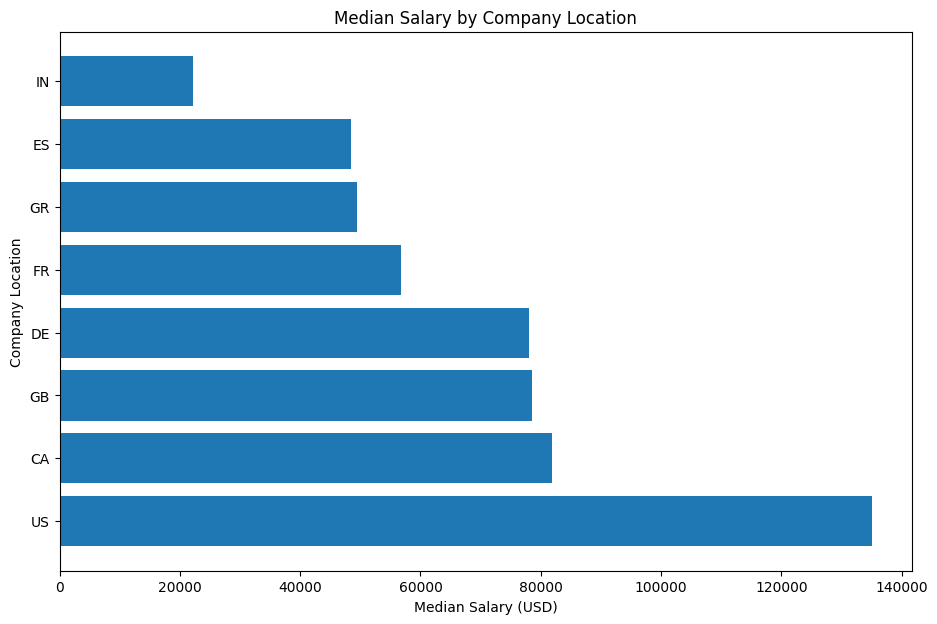

In [36]:
plt.figure(figsize=(11, 7))

plt.barh(
    top_locations_by_salary['company_location'],
    top_locations_by_salary['median']
)

plt.title('Median Salary by Company Location')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Company Location')

plt.show()

### Company Location and Salary Findings

The US has the highest median salary among the included locations, followed by Canada. India has the lowest. The number of records differs a lot between countries, so the results should be read with sample size in mind.


In [37]:
year_salary = (
    df.groupby('work_year')['salary_in_usd']
      .agg(['mean', 'median', 'count'])
      .reset_index()
)

year_salary

,work_year,mean,median,count
0,2020,95813.000000,75544.0,72
1,2021,99853.792627,82528.0,217
2,2022,124522.006289,120000.0,318


### Salary Trend Over Time

Mean and median salaries are compared across the available years to see how salary levels changed over time.


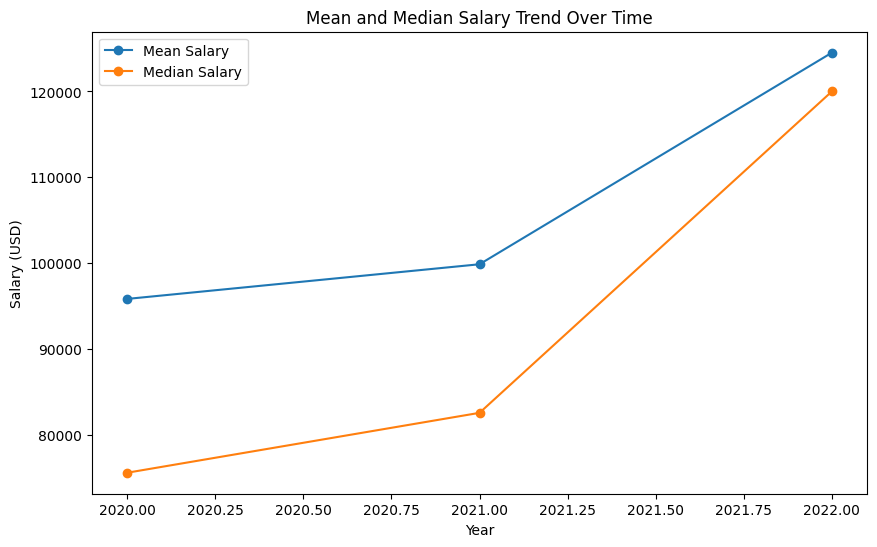

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_salary['work_year'],
    year_salary['mean'],
    marker='o',
    label='Mean Salary'
)

plt.plot(
    year_salary['work_year'],
    year_salary['median'],
    marker='o',
    label='Median Salary'
)

plt.title('Mean and Median Salary Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Salary (USD)')
plt.legend()

plt.show()

### Salary Trend Findings

Salary levels increased from 2020 to 2022. Mean salary rose from about $95.8K to $124.5K, while median salary rose from about $75.5K to $120K. The number of records also increased across the years.


## Data Scientist vs Data Analyst

### Business Question

Is there a meaningful salary difference between Data Scientists and Data Analysts?

We compare their mean, median, and number of records.


In [39]:
ds_da_salary = (
    df[df['job_title'].isin(['Data Scientist', 'Data Analyst'])]
    .groupby('job_title')['salary_in_usd']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

ds_da_salary

,job_title,mean,median,count
0,Data Analyst,92893.061856,90320.0,97
1,Data Scientist,108187.832168,103691.0,143


### Median Salary: Data Scientist vs Data Analyst

The two roles are compared using mean and median salary.


In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    ds_da_salary['job_title'],
    ds_da_salary['median']
)

plt.title('Median Salary: Data Scientist vs Data Analyst')
plt.xlabel('Job Title')
plt.ylabel('Median Salary (USD)')

plt.tight_layout()
plt.show()


### Data Scientist vs Data Analyst Findings

Data Scientists have higher salaries in the dataset. Their mean is about $108,188 versus $92,893 for Data Analysts, and their median is about $103,691 versus $90,320.


## Correlation Analysis

We use correlation to check the strength and direction of relationships between salary, work year, and remote-work ratio.


In [41]:
correlation_data = df[
    ['salary_in_usd', 'work_year', 'remote_ratio']
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,salary_in_usd,work_year,remote_ratio
salary_in_usd,1.000000,0.170493,0.132122
work_year,0.170493,1.000000,0.076314
remote_ratio,0.132122,0.076314,1.000000


### Correlation Findings

The correlations are weak:

- Salary and work year: **0.170**
- Salary and remote ratio: **0.132**
- Work year and remote ratio: **0.076**

So none of these variables has a strong linear relationship with salary.


### Correlation Heatmap

The heatmap gives a quick view of the correlations between the three numerical variables.


In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## Hypothesis Evaluation

The hypotheses are evaluated using the descriptive comparisons above. The results show meaningful salary differences across several groups.

These are descriptive findings; no statistical significance test or p-value was used.


## Research Questions — Summary of Findings

### 1. Does salary increase with experience level?
Yes. Salary generally increases from Entry-level to Executive-level roles.

### 2. Which job titles have the highest typical salaries?
Among the 10 most represented roles, Data Architect has the highest median salary.

### 3. Does company size relate to salary?
Yes. Small companies show lower typical salaries than Medium and Large companies.

### 4. Do salaries differ by remote-work arrangement?
Yes. Fully remote roles have the highest mean and median salaries in this dataset.

### 5. Which company locations have higher salaries?
The US has the highest median salary among the locations included in the comparison.

### 6. How do salaries change over time?
Salary levels increased across the available years, with the largest increase from 2021 to 2022.

### 7. Is there a salary difference between Data Scientists and Data Analysts?
Yes. Data Scientists have higher mean and median salaries in the dataset.


## Insights & Patterns

- Experience is strongly associated with salary differences.
- Data Scientists earn more than Data Analysts in the analyzed sample.
- Fully remote roles have the highest salary levels among the remote-work groups.
- Small companies show lower typical salaries than Medium and Large companies.
- The US has the highest median salary among the sufficiently represented locations.
- Salary levels increased from 2020 to 2022.
- Correlations with salary are weak, with work year showing the strongest of the three examined relationships (r = 0.170).


## EDA Conclusion

Salary varies across several factors in the dataset, especially experience, job role, company size, location, remote-work arrangement, and year.

Overall, the analysis suggests that salary differences are not explained by one factor alone. The findings can be used as the basis for the dashboard and business recommendations.
